# PREDICIENDO LAS VENTAS DE UNA TIENDA - Leticia Marticorena

Se trabajará en un modelo que pueda predecir las ventas mensuales de una tienda utilizando técnicas de análisis de series de tiempo. El objetivo principal es aplicar un enfoque de análisis y modelado de series de tiempo para realizar predicciones precisas de las ventas futuras.
La tienda ha recopilado datos históricos de ventas mensuales durante varios años, en el archivo **Sales_Data.xlsx**. 

Pasos a Realizar:
1. Descomposición de la Serie de Tiempo: Comienza descomponiendo la serie de tiempo en sus componentes principales: tendencia, estacionalidad y residuos. Utiliza métodos como el suavizamiento exponencial o la descomposición estacional para comprender la estructura subyacente de los datos.

2. Identificación de Parámetros ARIMA: Utiliza las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF) para identificar los posibles valores de los parámetros p (orden del término autorregresivo) y q (orden del término de media móvil) en el modelo ARIMA. Además, realiza el test de Dickey-Fuller para determinar si es necesario aplicar la diferenciación (valor d) para lograr la estacionaridad.

3. Modelado con ARIMA: Aplica el modelo ARIMA utilizando los parámetros identificados en el paso anterior. Ajusta el modelo a los datos históricos de ventas mensuales y realiza predicciones para los próximos meses.

4. Evaluación de Predicciones: Divide los datos históricos en un conjunto de entrenamiento y uno de prueba. Utiliza el conjunto de entrenamiento para ajustar el modelo ARIMA y luego evalúa las predicciones en el conjunto de prueba. Calcula métricas de evaluación como el error cuadrático medio (MSE) o el error absoluto medio (MAE) para medir el rendimiento del modelo.

In [3]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Series de Tiempo - Statsmodels
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

# Métricas
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

import warnings
warnings.filterwarnings('ignore')


In [4]:
# Carga de datos
df = pd.read_excel("Sales_data.xlsx")

print(df.shape)
df.head()

(48, 2)


,Order Date,Sales
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


### Revisión de los Datos

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  48 non-null     datetime64[ns]
 1   Sales       48 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 896.0 bytes


- Se observa que no hay nulos
- La columna 'Order Data' está en formato datatime64 => índice temporal
- La columna 'Sales' está en formato float64 (variable continua)
- La Frecuencia de los datos es mensual

### 1. DESCOMPOSICION DE LA SERIE DE TIEMPO: identificar tendencia, estacionalidad y residuo

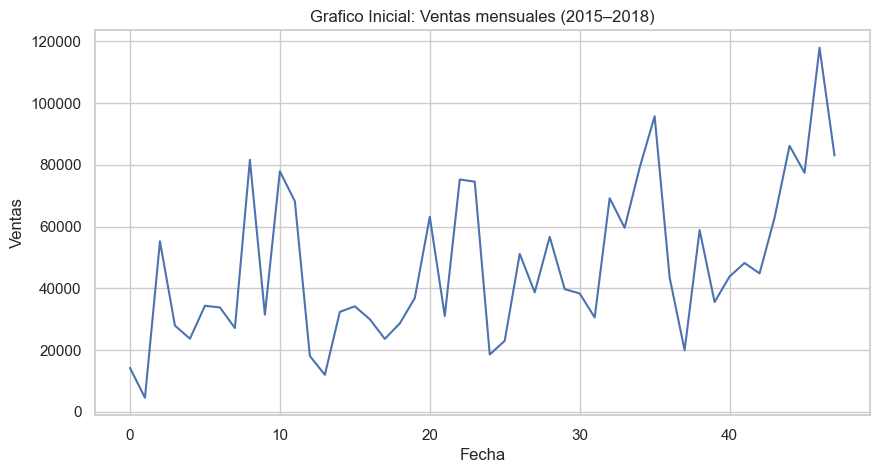

In [12]:
# Gráfico inicial de la serie

df["Sales"].plot()
plt.title("Grafico Inicial: Ventas mensuales (2015–2018)")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.show()


Se observa:
- Tendencia levemente creciente, con aumento los ultimos meses (48 datos en total)
- Variabilidad: se observa alta volatilidad (picos y caídas abruptas)
- Estacionalidad: se observa que durante los fines años (meses 10-12, 22-24, etc) los valores aumentan, lo que podría indicar cierta estacionalidad => se puede justificar aplicar pruebas formales (ADF) y quizás diferenciación

In [15]:
df = df.set_index("Order Date")  # Necesario para crear el indice
df = df.asfreq("MS")  # MS = Month Start

In [17]:
# Usaremos un Modelo de descomposición Aditivo (suponiendo estacionalidad anual)

decomposition = seasonal_decompose(
    df["Sales"],
    model="additive",  
    period=12      # estacionalidad anual (12 meses)
)

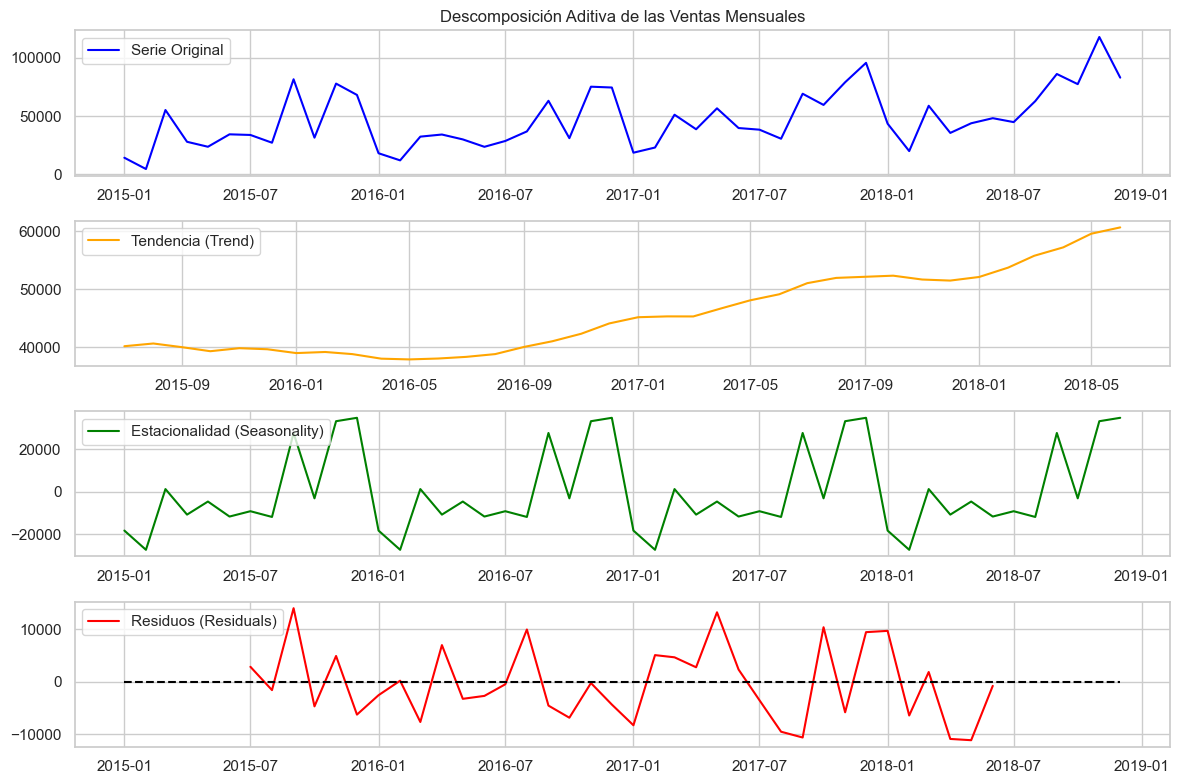

In [19]:
# Gráficos de tendencia, estacionalidad y residuo

# Extraemos los componentes de la descomposición
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Graficamos los componentes
plt.figure(figsize=(12, 8))

# Serie original
plt.subplot(411)
plt.plot(df['Sales'], label='Serie Original', color='blue')
plt.legend(loc='upper left')
plt.title('Descomposición Aditiva de las Ventas Mensuales')

# Tendencia
plt.subplot(412)
plt.plot(trend, label='Tendencia (Trend)', color='orange')
plt.legend(loc='upper left')

# Estacionalidad
plt.subplot(413)
plt.plot(seasonal, label='Estacionalidad (Seasonality)', color='green')
plt.legend(loc='upper left')

# Residuos
plt.subplot(414)
plt.plot(residual, label='Residuos (Residuals)', color='red')
plt.legend(loc='upper left')
plt.hlines(
    y=0,
    xmin=residual.index.min(),
    xmax=residual.index.max(),
    colors='black',
    linestyles='--'
)

plt.tight_layout()
plt.show()

**Observaciones:**

1. Tendencia (Trend): La tendencia pareciera ser creciente, pero del 2016-09 en adelante.
2. Estacionalidad (Seasonality): Se aprecia un patrón anual: valores negativos primer semestre, valores positivos segundo semestre. La magnitud de la estacionalidad se mantiene relativamente constante => se justifica modelo aditivo.
3. Residuos (Residuals): Se encuentran alrededor de cero, no se observan patrones fuertes => se justifica modelo aditivo.

### 2. PARAMETROS ARIMA

#### Test de Dickey-Fuller Aumentado (ADF): buscando parámetro d

Usamos el Test de Dickey-Fuller Aumentado (ADF) para verificar si la serie es estacionaria

- H0 (Hipótesis Nula): La serie NO es estacionaria
- H1 (Hipótesis Alternativa): La serie es estacionaria

- Si p-value < 0.05: Rechazamos H0 => la serie ES estacionaria
- Si p-value > 0.05: No es estacionaria (tiene tendencia) => Aplicamos Diferenciación (restar el valor actual con el anterior, hasta que sea estacionaria, d= número de veces que diferenciamos).

In [25]:
def test_stationarity(timeseries): # Función obtenida de clases
    
    print('Resultados del Test de Dickey-Fuller:')
    dftest = adfuller(timeseries, autolag='AIC')
    p_value = dftest[1]
    
    print(f"- Estadístico de prueba: {dftest[0]:.4f}")
    print(f"- p-value: {p_value:.6f}")
    
    if p_value <= 0.05:
        print("La serie ES estacionaria.")
    else:
        print("La serie NO es estacionaria (tiene tendencia/varianza).")
    return p_value

In [27]:
# Test inicial
test_stationarity(df['Sales'])

Resultados del Test de Dickey-Fuller:
- Estadístico de prueba: -4.4161
- p-value: 0.000278
La serie ES estacionaria.


0.00027791039276670623

Conclusión: **LA SERIE ES ESTACIONARIA => d=0**

Para usar **Modelo ARIMA** necesitamos los parámetros p, d y q:

- p: AR- Regresión sobre el pasado => ACF
- d: I- Integración => en este caso **d=0**, ya que la serie es estacionaria
- q: MA- Error de media móvil => PACF

#### Parámetros p y q (ACF Y PACF)

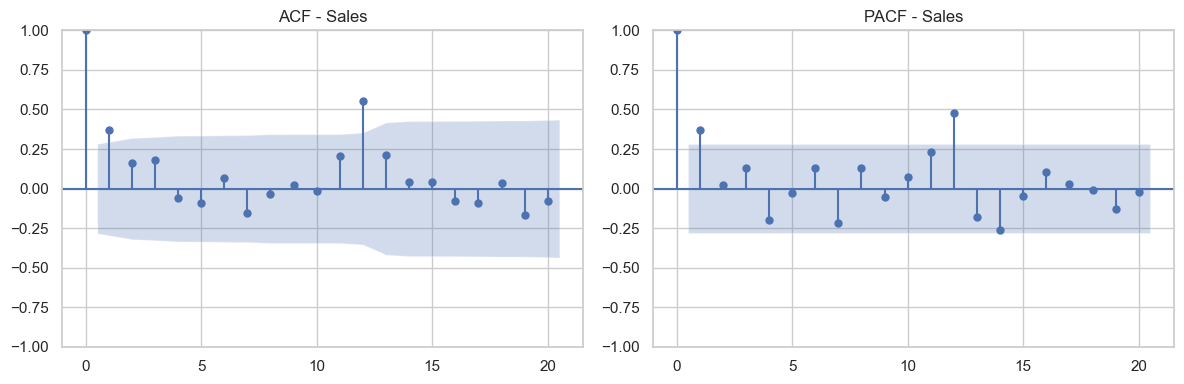

In [31]:
# Graficando ACF Y PACF

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(df["Sales"], lags=20, ax=ax[0])
ax[0].set_title("ACF - Sales")

plot_pacf(df["Sales"], lags=20, method="ywm", ax=ax[1])
ax[1].set_title("PACF - Sales")

plt.tight_layout()
plt.show()

**Buscando p y q**

Para ambos ACF y PACF:
- lag1: valor significativo 
- Entre lag2-lag11: valores insignificantes
- lag12: aparece un pico que es consistente con estacionalidad anual

Entonces, 
- p (componente AutoRegresivo AR, de PACF): cuántos valores pasados de la serie se usan para predecir el valor actual => *lag* significativo de PACF
- q (componente de Media Móvil MA, de ACF): cuántos errores pasados influyen en el valor actual => *lag* significativo de ACF

Por lo tanto, ==> **p=1 / q=1**

### 3. MODELADO CON ARIMA (datos completos y datos entrenamiento)

In [35]:
# Modelo ARIMA(p=1, d=0, q=1) ... se hará con los datos completos, sin entrenamiento previo aún

model = ARIMA(df["Sales"], order=(1, 0, 1))
results = model.fit()

print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   48
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -549.516
Date:                Mon, 22 Dec 2025   AIC                           1107.033
Time:                        17:23:00   BIC                           1114.518
Sample:                    01-01-2015   HQIC                          1109.861
                         - 12-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.712e+04   6372.221      7.394      0.000    3.46e+04    5.96e+04
ar.L1          0.6655      0.280      2.373      0.018       0.116       1.215
ma.L1         -0.3053      0.353     -0.865      0.3

**Observaciones Arima (data completa):**

1. **AIC = 1107.033** (con los 48 meses)
2. BIC = 1114.518
4. ar.L1   coef = 0.6655   P= 0.018 => es significativo
5. ma.L1   coef = -0.3053  P= 0.387 => No es significativo
6. "Standard errors may be unstable": Esto puede significar alta colinealidad entre parámetros, lo que puede dificultar el estimar con precisión algunos coeficientes.

#### Modelado ARIMA con datos train/test

In [39]:
# ENTRENAMIENTO DEL MODELO (36 meses Train / 12 últimos meses Test)

train = df.iloc[:-12]
test = df.iloc[-12:]

In [41]:
model_train = ARIMA(train["Sales"], order=(1, 0, 1))
results_train = model_train.fit()

print(results_train.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   36
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -411.018
Date:                Mon, 22 Dec 2025   AIC                            830.036
Time:                        17:24:05   BIC                            836.370
Sample:                    01-01-2015   HQIC                           832.247
                         - 12-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.276e+04   5457.566      7.836      0.000    3.21e+04    5.35e+04
ar.L1          0.5294      0.585      0.905      0.366      -0.618       1.676
ma.L1         -0.2659      0.661     -0.402      0.6

**Observaciones Arima train:**

1. Constante= 42760, P= 0.000 => Significativa (nivel medio de ventas mensuales= 42.700 unidades)
2. ar.L1= 0.529, P= 0.366 => No significativo 
3. ma.L1= -0.266, P= 0.687 => No significativo
4. sigma2= 4.653e+08, P= 0.000 => No significativo
5. AIC (train)= 830.036  <  AIC (data completa)= 1107.033 => se ajustan mejor loa datos en el entrenamiento

In [46]:
# Predicción de ventas futuras Modelo ARIMA (sobre data test)

forecast_test = results_train.forecast(steps=len(test))

forecast_test = pd.Series(
    forecast_test,
    index=test.index,
)

forecast_test

Order Date
2018-01-01    59690.488987
2018-02-01    51724.079045
2018-03-01    47506.921775
2018-04-01    45274.496432
2018-05-01    44092.723358
2018-06-01    43467.131285
2018-07-01    43135.963271
2018-08-01    42960.653739
2018-09-01    42867.850597
2018-10-01    42818.723645
2018-11-01    42792.717441
2018-12-01    42778.950605
Freq: MS, Name: predicted_mean, dtype: float64

In [48]:
# Comparación Datos Reales / Predicción (test)

comparacion_arima = pd.concat(
    [
        test["Sales"].rename("Ventas Reales"),
        forecast_test.rename("Predicción ARIMA (test)")
    ],
    axis=1
)

comparacion_arima

,Ventas Reales,Predicción ARIMA (test)
Order Date,,
2018-01-01,43476.4740,59690.488987
2018-02-01,19920.9974,51724.079045
2018-03-01,58863.4128,47506.921775
2018-04-01,35541.9101,45274.496432
2018-05-01,43825.9822,44092.723358
2018-06-01,48190.7277,43467.131285
2018-07-01,44825.1040,43135.963271
2018-08-01,62837.8480,42960.653739
2018-09-01,86152.8880,42867.850597


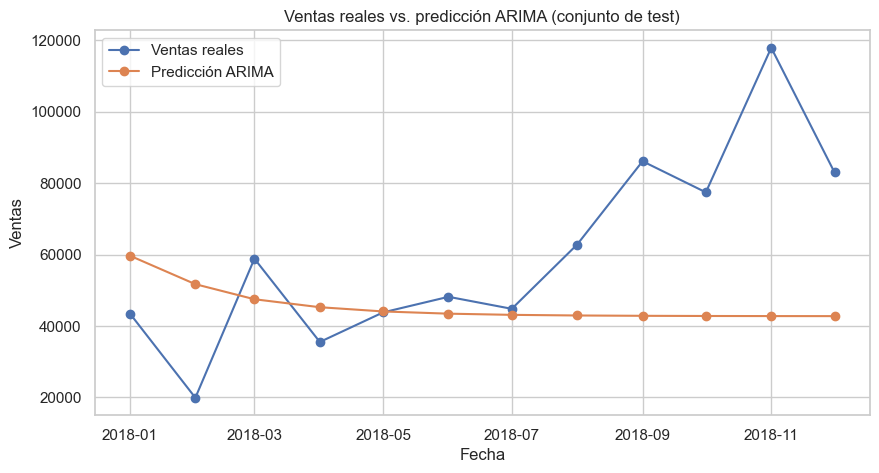

In [50]:
# Grafico de comparación

plt.figure(figsize=(10, 5))
plt.plot(comparacion_arima.index, comparacion_arima["Ventas Reales"], label="Ventas reales", marker="o")
plt.plot(comparacion_arima.index, comparacion_arima["Predicción ARIMA (test)"], label="Predicción ARIMA", marker="o")

plt.title("Ventas reales vs. predicción ARIMA (conjunto de test)")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)

plt.show()

**Observaciones:**
1. Las predicciones convergen a un valor constante (43.000 aprox), vs. los valores reales tienen mucha variación (altos/bajos) y presentan estacionalidad.
2. La tendencia general de la predicción es decreciente (leve), tendiendo a una constante, pero los valores reales tienen una tendencia global creciente, esto en la segunda mitad de la data.

==> NO es un buen modelo predictivo

#### Modelo Auto-ARIMA

In [54]:
# Modelo Auto-ARIMA: busca automáticamente los parámetros p, d y q 

# Entrenando el modelo con datos train

auto_model = auto_arima(
    train["Sales"],         # Sobre datos de entrenamiento
    seasonal=False,         # ARIMA clásico, sin estacionalidad
    d=0,                    # ya sabemos que es estacionaria
    trace=False,            
    stepwise=True,
    suppress_warnings=True
)

print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   36
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -411.081
Date:                Mon, 22 Dec 2025   AIC                            828.162
Time:                        17:24:52   BIC                            832.913
Sample:                    01-01-2015   HQIC                           829.820
                         - 12-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   3.239e+04   7843.452      4.130      0.000     1.7e+04    4.78e+04
ar.L1          0.2514      0.155      1.625      0.104      -0.052       0.555
sigma2      4.745e+08      0.101    4.7e+09      0.0

**Observaciones:**

- Mejor Modelo encontrado: ARIMA(1,0,0) 
- AIC= 828.16 (mejor que AIC 830.036 de ARIMA(1,0,1))

==> Auto_ARIMA(1,0,0) es mejor, aunque sigue siendo limitado

In [57]:
#  Predicción de ventas futuras para modelo Auto-ARIMA (data test)

forecast_auto_test = auto_model.predict(n_periods=len(test))

forecast_auto_test = pd.Series(
    forecast_auto_test,
    index=test.index,
    name="Predicción Auto_ARIMA (1,0,0)"
)

forecast_auto_test

Order Date
2018-01-01    56464.970512
2018-02-01    46589.505802
2018-03-01    44106.325337
2018-04-01    43481.930901
2018-05-01    43324.927245
2018-06-01    43285.448758
2018-07-01    43275.521912
2018-08-01    43273.025812
2018-09-01    43272.398169
2018-10-01    43272.240349
2018-11-01    43272.200665
2018-12-01    43272.190686
Freq: MS, Name: Predicción Auto_ARIMA (1,0,0), dtype: float64

In [59]:
comparacion_auto = pd.concat(
    [
        test["Sales"].rename("Ventas Reales"),
        forecast_test.rename("Predicción ARIMA (test)"),
        forecast_auto_test.rename("Predicción Auto_ARIMA (test)")
    ],
    axis=1
)

comparacion_auto

,Ventas Reales,Predicción ARIMA (test),Predicción Auto_ARIMA (test)
Order Date,,,
2018-01-01,43476.4740,59690.488987,56464.970512
2018-02-01,19920.9974,51724.079045,46589.505802
2018-03-01,58863.4128,47506.921775,44106.325337
2018-04-01,35541.9101,45274.496432,43481.930901
2018-05-01,43825.9822,44092.723358,43324.927245
2018-06-01,48190.7277,43467.131285,43285.448758
2018-07-01,44825.1040,43135.963271,43275.521912
2018-08-01,62837.8480,42960.653739,43273.025812
2018-09-01,86152.8880,42867.850597,43272.398169


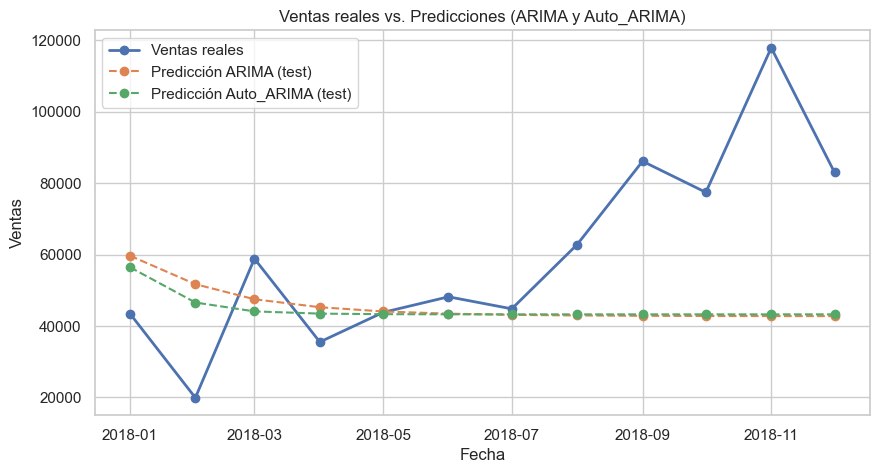

In [61]:
# Gráfico comparativo Ventas Reales vs Predicciones (ARIMA y Auto_ARIMA)

plt.figure(figsize=(10, 5))

plt.plot(
    comparacion_auto.index,
    comparacion_auto["Ventas Reales"],
    label="Ventas reales",
    marker="o",
    linewidth=2
)

plt.plot(
    comparacion_auto.index,
    comparacion_auto["Predicción ARIMA (test)"],
    label="Predicción ARIMA (test)",
    marker="o",
    linestyle="--"
)

plt.plot(
    comparacion_auto.index,
    comparacion_auto["Predicción Auto_ARIMA (test)"],
    label="Predicción Auto_ARIMA (test)",
    marker="o",
    linestyle="--"
)

plt.title("Ventas reales vs. Predicciones (ARIMA y Auto_ARIMA)")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)

plt.show()

**Observaciones:**

Hay diferencias menores entre modelo Arima y modelo Auto_Arima:
- Ambos modelos (ARIMA y Auto_ARIMA) convergen a un valor constante (entre 43.000-47.000) => los modelos se acercan al nivel medio de la serie
- Ambos modelos no pueden capturar valores picos, y se observan valores muy distintos a los reales
- Modelo Auto_Arima es más plano, y Modelo ARIMA(1,0,1) comienza un poco más alto, pero termina convergiendo igual.
- AIC levemente mejor en modelo Auto_Arima (828 Auto_arima vs. 830 Arima).

### 4. EVALUACION DE LAS PREDICCIONES

#### Metricas de evaluación

In [66]:
# Cálculo de métricas MAE, MSE, RMSE sobre datos test

y_true = np.array(test)
y_pred_arima = np.array(forecast_test)
y_pred_auto = np.array(forecast_auto_test)

# MAE
mae_arima = mean_absolute_error(y_true, y_pred_arima)
mae_auto = mean_absolute_error(y_true, y_pred_auto)

# RMSE
rmse_arima = np.sqrt(mean_squared_error(y_true, y_pred_arima))
rmse_auto = np.sqrt(mean_squared_error(y_true, y_pred_auto))

# RSE
mean_y = np.mean(y_true)

rse_arima = np.sum((y_true - y_pred_arima)**2) / np.sum((y_true - mean_y)**2)
rse_auto = np.sum((y_true - y_pred_auto)**2) / np.sum((y_true - mean_y)**2)


In [68]:
# Tabla comparativa 

resultados = pd.DataFrame({
    'Modelo': ['ARIMA (1,0,1)', 'Auto-ARIMA (1,0,0)'],
    'MAE': [mae_arima, mae_auto],
    'RMSE': [rmse_arima, rmse_auto],
    'RSE': [rse_arima, rse_auto]
})

resultados

,Modelo,MAE,RMSE,RSE
0,"ARIMA (1,0,1)",24081.180605,31961.133121,16.177544
1,"Auto-ARIMA (1,0,0)",23362.948707,31268.553439,16.529126


**Observaciones:**

1. MAE: Auto-ARIMA tiene menor MAE (leve): En promedio se equivoca 700 unidades aprox menos que ARIMA (1,0,1)
2. RMSE: Auto-ARIMA también tiene menor RMSE (leve): Penaliza más los errores grandes 
3. RSE: RSE >> 1 en ambos modelos: Ambos modelos son mucho peores que predecir usando solo la media del período de test
==> Aunque el modelo Auto-ARIMA (1,0,0) presenta valores ligeramente menores de MAE y RMSE respecto al ARIMA (1,0,1), ambos modelos muestran valores de RSE considerablemente mayores a 1, indicando un bajo desempeño predictivo en el período de prueba.

**Conclusiones finales:**

1. La Serie original tiene alta variabilidad y picos, con cambios bruscos => ARIMA no maneja bien picos ni saltos
2. Serie con pocos datos
3. Los modelos no predicen bien, quizás es necesario aplicar otros modelos.